In [27]:
! apt install tesseract-ocr
! apt install libtesseract-dev
! apt-get install tesseract-ocr-jpn

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 29 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libtesseract-dev is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 29 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tesseract-ocr-jpn
0 upgraded, 1 newly installed, 0 to remove and 29 not upgraded.
Need to get 1,390 kB of archives.
After this operation, 2,486 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-jpn all 1:4.00~git30-7274cfa-1.1 [1,390 kB]
Fetched 1,390 kB in 1s (2,377 kB/s)
Selecting previously unselected package tesseract-ocr-jpn.
(Read

In [2]:
!pip install -q torch bitsandbytes transformers accelerate openai pandas matplotlib gradio pymupdf pytesseract pdf2image tesseract

In [64]:
import torch
from PIL import Image
import requests
from transformers import AutoProcessor, LlavaNextForConditionalGeneration, BitsAndBytesConfig, LlavaForConditionalGeneration
from huggingface_hub import login
# from dotenv import load_dotenv
import openai
from openai import OpenAI
import logging
import os
from tqdm import tqdm
import json
import time
import base64
import fitz
from concurrent.futures import ThreadPoolExecutor
import pandas as pd
import matplotlib.pyplot as plt
import gradio as gr
import pytesseract
import pdf2image
import cv2
import numpy as np
import shutil

In [4]:
from google.colab import drive, userdata

In [5]:
# pytesseract.pytesseract.tesseract_cmd = r'/usr/local/bin/pytesseract'
# pytesseract.pytesseract.tesseract_cmd = ( r'/usr/bin/tesseract' )

In [6]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
fRoot = "/content/drive/MyDrive/Colab Notebooks"

In [8]:
# load_dotenv()
# os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')
# os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
# os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY', 'your-key-if-not-using-env')
# openai = OpenAI()
hf_token = userdata.get('HF_TOKEN')
openai_api_key = userdata.get('OPENAI_API_KEY')

# Configure the huggingface_hub logger to suppress warnings
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

# Login using the token
login(hf_token, add_to_git_credential=True)

logging.getLogger("huggingface_hub").setLevel(logging.INFO)

## Create a Specific Prompt for Japanese Text Extraction
Let's create a specialized prompt that asks the model to:

1. Ignore furigana
2. Preserve structure
3. Output in JSON format

In [53]:
def get_system_prompt():
    return """
    This image contains Japanese text from a textbook with furigana (small kana above kanji).
    Furthermore you are provided with the result of an OCR extraction which is however faulty and multiple points mainly due to the furigana.
    However the OCR does typically capture the structure of the document very accurately.

    The Exercises you should extract have the following structure in the image:
    - Each new exercise starts with a consecutive number followed by a dot e.g. 1., 2., etc
    - For each exercise there is a number of examples where each example consists of one or multiple sentences. Each Example starts with a consecutive number (independent of the exercise) followed by a closing bracket e.g. 1), 2) etc.
    - Each example does not end until either a new example or exercise starts i.e. before a new number followed by either a dot or a closing bracket is encountered.
    - Some examples consist of a question answer scheme, where the answer can begin with a number of dots. These should still be treated as a single example e.g. どうしてケーキを食べないんですか。……ダイエットをしているんです。
    - Each exercise belongs to a chapter which holds until the next chapter has been identified where a chapter is just a simple number
    - Each exercise belongs to a section where a chapter has one or multiple sections. This section holds until a new section has been identified. The section is a name which currently are 練習 B, 練習 C but might take on different values.

    There are some additional considerations for specific types of sections that might help:
    - 練習 C: The examples consist of multiple subanswers which have a circled number in front of them. Keep these circeled numbers (unicode u+2460 to u+2473) and consider them as a single example e.g. ①かばん ②店の地図をかいて

    Task:
    1. Analyze the image and extract the main Japanese text keeping the OCR input in mind.
    2. IGNORE all furigana (small kana characters above kanji)
    3. Preserve correct sentence structure and punctuation
    4. Output the text in JSON format with this structure:
       {
         "chapter": "chapter_number",
         "sections": [
           {
             "section": "section_name",
             "exercises": [
               {
                 "number": "exercise_number",
                 "sentences": ["example1", "example2", ...]
               }
             ]
           }
       }

    If chapter, section or exercise numbers aren't visible, use null values.
    Return ONLY the JSON output, nothing else.
    """

## Using LLaVa-Next Model
https://huggingface.co/docs/transformers/model_doc/llava_next

# Load model and processor
model_id = "llava-hf/llama3-llava-next-8b-hf"  # You can also try the larger variant
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4"
)
processor = AutoProcessor.from_pretrained(model_id)
model = LlavaNextForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=quant_config,
    device_map="auto",
    low_cpu_mem_usage=True
)

In [ ]:
def load_quantized_llava(quant_4bit=True, quant_8bit=True):
    """Load LLaVA-NeXT model with 8-bit quantization"""
    # model_id = "llava-hf/llama3-llava-next-8b-hf"
    model_id = "llava-hf/llava-1.5-7b-hf"
    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_quant_type="nf4"
    )

    # Install required packages if they don't exist
    try:
        import bitsandbytes
    except ImportError:
        print("Installing bitsandbytes...")
        !pip install -q bitsandbytes
        import bitsandbytes

    # Load processor normally
    processor = AutoProcessor.from_pretrained(model_id)

    # Load model with 8-bit quantization
    # if quant_4bit:
    #     model = LlavaNextForConditionalGeneration.from_pretrained(
    #         model_id,
    #         quantization_config=quant_config,
    #         device_map="auto",
    #         low_cpu_mem_usage=True
    #     )
    # elif quant_8bit:
    #     model = LlavaNextForConditionalGeneration.from_pretrained(
    #         model_id,
    #         load_in_8bit=True,  # Enable 8-bit quantization
    #         device_map="auto",
    #         torch_dtype=torch.float16
    #     )
    # else:
    #     model = LlavaNextForConditionalGeneration.from_pretrained(
    #         model_id,
    #         device_map="auto",
    #         torch_dtype=torch.float16
    #     )
    if quant_4bit:
        model = LlavaForConditionalGeneration.from_pretrained(
            model_id,
            quantization_config=quant_config,
            device_map="auto",
            low_cpu_mem_usage=True
        )
    elif quant_8bit:
        model = LlavaForConditionalGeneration.from_pretrained(
            model_id,
            load_in_8bit=True,  # Enable 8-bit quantization
            device_map="auto",
            torch_dtype=torch.float16
        )
    else:
        model = LlavaForConditionalGeneration.from_pretrained(
            model_id,
            device_map="auto",
            torch_dtype=torch.float16
        )

    return model, processor

In [55]:
def process_image_with_llava(image_path, text_system_prompt, text_user_prompt, model, processor):
    # Load image
    if image_path.startswith('http'):
        image = Image.open(requests.get(image_path, stream=True).raw)
    else:
        image = Image.open(image_path)

    # Define a chat histiry and use `apply_chat_template` to get correctly formatted prompt
    # Each value in "content" has to be a list of dicts with types ("text", "image")
    conversation = [
        {
          "role": "system",
          "content": [
              {"type": "text", "text": text_system_prompt},],
        },
        {
          "role": "user",
          "content": [
              {"type": "text", "text": text_user_prompt},
              {"type": "image"},
            ],
        },
    ]

    prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)

    # Process inputs
    inputs = processor(text=prompt, images=image, return_tensors="pt").to(model.device)

    # Generate response
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=1024,
            do_sample=False
        )

    # Decode and return response
    response = processor.decode(output[0], skip_special_tokens=True)
    return response.strip()

## Using GPT-4o for Comparison

In [56]:
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

def process_with_gpt(image_path, text_system_prompt, text_user_prompt, model="gpt-4o-mini", api_key=None):
    if api_key:
        openai.api_key = api_key
    elif not openai.api_key:
        raise ValueError("OpenAI API key is required")

    base64_image = encode_image(image_path)

    try:
        response = openai.chat.completions.create(
            model=model,
            messages=[
                {
                    "role": "system",
                    "content": [
                        {"type": "text", "text": text_system_prompt},
                    ]
                },
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": text_user_prompt},
                        {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_image}"}}
                    ]
                }
            ]
        )

        return response.choices[0].message.content
    except Exception as e:
        print(f"Error with {model}: {str(e)}")
        return None

## Process PDF Pages

In [57]:
def convert_pdf_to_images(pdf_path, output_dir, remove_furigana=False):
    """Convert PDF pages to images"""
    os.makedirs(output_dir, exist_ok=True)
    doc = fitz.open(pdf_path)
    page_images = []

    for page_num in tqdm(range(len(doc)), desc="Converting PDF pages to images"):
        page = doc[page_num]

        # Convert page to image (2x zoom for better quality)
        pix = page.get_pixmap(matrix=fitz.Matrix(2, 2))
        img_path = f"{output_dir}/page_{page_num}.png"
        pix.save(img_path)
        page_images.append((page_num, img_path))

    for page_num in tqdm(range(len(doc)), desc="Converting PDF pages to images with removed furigana"):
        img_path = f"{output_dir}/page_{page_num}.png"
        cleaned_img_np = remove_furigana_v2(img_path)
        cleaned_img = Image.fromarray(cleaned_img_np)
        cleaned_img.save(f"{output_dir}/page_{page_num}_no_furigana.png")

    return page_images

In [58]:
def process_page(args):
    """Process a single page with selected models"""
    page_num, img_path, models = args
    results = {}

    # Japanese text extraction prompt (same for all models)
    text_system_prompt = get_system_prompt()
    ocr_text = pytesseract.image_to_string(Image.open(img_path), config=r'--oem 3 --psm 6 -l jpn')
    text_user_prompt = f"""Here is the result of the OCR extraction which you should consider as an additional reference
    when extracting the Japanese text from the image, especially with regards to the structure of the document:
    {ocr_text}"""

    # Process with LLaVA if enabled
    if "llava" in models and models["llava"]:
        model, processor = models["llava"]
        llava_result = process_image_with_llava(img_path, text_system_prompt, text_user_prompt, model, processor)
        try:
            llava_json = json.loads(llava_result)
            llava_json["page_number"] = page_num + 1
            results["llava"] = llava_json
        except (json.JSONDecodeError, TypeError) as e:
            print(f"Could not parse LLaVA JSON from page {page_num+1}: {str(e)}")
            results["llava"] = {"error": str(e), "raw": llava_result[:200] + "..." if llava_result else None}

    # Process with GPT-4o if enabled
    if "gpt4o" in models and models["gpt4o"]:
        # Add a delay to avoid rate limiting
        time.sleep(1)
        gpt4o_result = process_with_gpt(img_path, text_system_prompt, text_user_prompt, "gpt-4o", models["api_key"])
        try:
            gpt4o_json = json.loads(gpt4o_result)
            gpt4o_json["page_number"] = page_num + 1
            results["gpt4o"] = gpt4o_json
        except (json.JSONDecodeError, TypeError) as e:
            print(f"Could not parse GPT-4o JSON from page {page_num+1}: {str(e)}")
            results["gpt4o"] = {"error": str(e), "raw": gpt4o_result[:200] + "..." if gpt4o_result else None}

    # Process with GPT-4o mini if enabled
    if "gpt4o_mini" in models and models["gpt4o_mini"]:
        # Add a delay to avoid rate limiting
        time.sleep(1)
        mini_result = process_with_gpt(img_path, text_system_prompt, text_user_prompt, "gpt-4o-mini", models["api_key"])
        try:
            mini_json = json.loads(mini_result)
            mini_json["page_number"] = page_num + 1
            results["gpt4o_mini"] = mini_json
        except (json.JSONDecodeError, TypeError) as e:
            print(f"Could not parse GPT-4o mini JSON from page {page_num+1}: {str(e)}")
            results["gpt4o_mini"] = {"error": str(e), "raw": mini_result[:200] + "..." if mini_result else None}

    return results

In [65]:
def process_pdf_multimodel(pdf_path, output_dir, use_llava=True, use_gpt4o=False, use_gpt4o_mini=False, openai_api_key=None, max_workers=4):
    """Process a PDF with multiple models in parallel"""
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)

    # First, convert PDF to images
    page_images = convert_pdf_to_images(pdf_path, output_dir, True)

    # Load models as needed
    models = {
        "api_key": openai_api_key
    }

    if use_llava:
        # print("Loading LLaVA-NeXT model...")
        print("Loading LLaVA model...")
        models["llava"] = load_quantized_llava()
        # print("LLaVA-NeXT model loaded successfully")
        print("LLaVA model loaded successfully")

    if use_gpt4o:
        models["gpt4o"] = True
        if not openai_api_key:
            raise ValueError("OpenAI API key is required for GPT-4o")

    if use_gpt4o_mini:
        models["gpt4o_mini"] = True
        if not openai_api_key:
            raise ValueError("OpenAI API key is required for GPT-4o mini")

    # Process pages in parallel
    process_args = [(page_num, img_path, models) for page_num, img_path in page_images]

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = list(tqdm(
            executor.map(process_page, process_args),
            total=len(process_args),
            desc="Processing pages with models"
        ))

    # Organize results by model
    organized_results = {
        "llava": [],
        "gpt4o": [],
        "gpt4o_mini": []
    }

    for page_result in results:
        for model_name in organized_results.keys():
            if model_name in page_result and "error" not in page_result[model_name]:
                organized_results[model_name].append(page_result[model_name])

    # Save raw results for each model
    for model_name, model_results in organized_results.items():
        if model_results:
            with open(f"{output_dir}/{model_name}_results.json", "w", encoding="utf-8") as f:
                json.dump(model_results, f, ensure_ascii=False, indent=2)

    return organized_results

## Validation and Post-Processing
Add a validation step to ensure the JSON output is correctly formatted:

In [60]:
def validate_and_clean_results(results, model_name):
    """Clean and merge results by chapter"""
    cleaned_results = []

    for page_result in results:
        if isinstance(page_result, dict) and "exercises" in page_result:
            cleaned_results.append(page_result)
        else:
            print(f"Skipping invalid {model_name} result for page {page_result.get('page_number', 'unknown')}")

    # Merge results by chapter
    merged_results = {}
    for result in cleaned_results:
        chapter = result.get("chapter")
        if chapter not in merged_results:
            merged_results[chapter] = {"chapter": chapter, "exercises": []}

        # Append exercises
        merged_results[chapter]["exercises"].extend(result.get("exercises", []))

    return list(merged_results.values())

In [61]:
def compare_model_results(model_results_dict):
    """Compare results between different models"""
    comparison = {
        "summary": {},
        "details": []
    }

    # Get list of models with results
    models = [model for model, results in model_results_dict.items() if results]

    if len(models) <= 1:
        return {"message": "Need at least two models with results to compare"}

    # Add summary stats for each model
    for model in models:
        results = model_results_dict[model]
        comparison["summary"][f"{model}_chapters"] = len(results)
        comparison["summary"][f"{model}_exercises"] = sum(len(chapter.get("exercises", [])) for chapter in results)

    # Find chapters that exist in all models
    chapter_sets = {model: {chapter.get("chapter") for chapter in model_results_dict[model]} for model in models}
    common_chapters = set.intersection(*chapter_sets.values())
    comparison["summary"]["common_chapters"] = len(common_chapters)

    # Compare common chapters in detail
    chapter_data = {
        model: {chapter.get("chapter"): chapter for chapter in model_results_dict[model]}
        for model in models
    }

    for chapter_id in common_chapters:
        chapter_comparison = {"chapter": chapter_id}

        # Get exercises from each model
        exercises_by_model = {
            model: {ex.get("number"): ex for ex in chapter_data[model][chapter_id].get("exercises", [])}
            for model in models
        }

        # Find common exercises
        exercise_sets = {model: set(exs.keys()) for model, exs in exercises_by_model.items()}
        common_exercises = set.intersection(*exercise_sets.values())

        chapter_comparison["common_exercises"] = len(common_exercises)
        for model in models:
            chapter_comparison[f"{model}_exercises"] = len(exercises_by_model[model])

        # Compare sentences for common exercises
        differences = []
        for ex_num in common_exercises:
            sentences_by_model = {
                model: exercises_by_model[model][ex_num].get("sentences", [])
                for model in models
            }

            # Check if all models have the same sentences
            first_model = models[0]
            reference_sentences = sentences_by_model[first_model]

            has_differences = False
            for model in models[1:]:
                if sentences_by_model[model] != reference_sentences:
                    has_differences = True
                    break

            if has_differences:
                diff_entry = {"exercise": ex_num}
                for model in models:
                    diff_entry[f"{model}_sentences"] = sentences_by_model[model]
                differences.append(diff_entry)

        chapter_comparison["differences"] = differences
        comparison["details"].append(chapter_comparison)

    return comparison

In [18]:
def remove_furigana_v2(image_path):
    """Remove small furigana without affecting diacritics or punctuation."""

    # Read image using OpenCV
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply adaptive thresholding (enhance contrast)
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 25, 15)

    # Detect contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Compute median height of all text blocks
    heights = [cv2.boundingRect(cnt)[3] for cnt in contours]
    median_height = np.median(heights)

    # Remove only small text *above* kanji, keeping punctuation & diacritics
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)

        # Condition: Likely furigana if it's small and positioned above a larger block
        if h < median_height * 0.6:  # Small text (likely furigana)
            # Ensure it's positioned above another text block (to avoid diacritics)
            below_y = y + h + 5  # Check a bit below the detected text
            below_region = gray[below_y:below_y + 5, x:x + w]

            # If there's a solid region below, it's furigana → remove it
            if np.mean(below_region) < 200:  # Darker means text is present
                cv2.rectangle(gray, (x, y), (x + w, y + h), (255, 255, 255), -1)

    return gray

# Full Pipeline
Putting it all together

In [62]:
def extract_japanese_text_from_pdf(
   pdf_path,
   output_dir="output",
   use_llava=True,
   use_gpt4o=False,
   use_gpt4o_mini=False,
   openai_api_key=None,
   max_workers=4
):
   """Main function to extract Japanese text from PDF with multiple models"""
   print(f"Processing PDF: {pdf_path}")

   # Process PDF with selected models
   raw_results = process_pdf_multimodel(
       pdf_path,
       output_dir,
       use_llava=use_llava,
       use_gpt4o=use_gpt4o,
       use_gpt4o_mini=use_gpt4o_mini,
       openai_api_key=openai_api_key,
       max_workers=max_workers
   )

   # Validate and clean results for each model
   final_results = {}

   for model_name, model_results in raw_results.items():
       if model_results:
           final_results[model_name] = validate_and_clean_results(model_results, model_name)

           # Save final structured results
           with open(f"{output_dir}/final_{model_name}_structured.json", "w", encoding="utf-8") as f:
               json.dump(final_results[model_name], f, ensure_ascii=False, indent=2)

   # Compare results if multiple models were used
   if len(final_results) > 1:
       comparison = compare_model_results(final_results)
       with open(f"{output_dir}/model_comparison.json", "w", encoding="utf-8") as f:
           json.dump(comparison, f, ensure_ascii=False, indent=2)

       print(f"Model comparison saved to {output_dir}/model_comparison.json")

   print(f"Processing complete. Results saved to {output_dir}/")
   return final_results

# Using it

## Using all the models

In [ ]:
# Example Jupyter notebook usage

# Install required packages
!pip install -q transformers accelerate bitsandbytes torch pillow pymupdf tqdm

openai_api_key = userdata.get('OPENAI_API_KEY')

# Process a PDF with multiple models
results = extract_japanese_text_from_pdf(
    pdf_path="your_textbook.pdf",
    output_dir="japanese_extraction_output",
    use_llava=True,              # Use LLaVA-NeXT
    use_gpt4o=True,              # Use GPT-4o
    use_gpt4o_mini=True,         # Use GPT-4o mini
    openai_api_key=openai_api_key,
    max_workers=4                # Adjust based on your system
)

# Examine the results
for model, data in results.items():
    print(f"\n{model} extracted {len(data)} chapters")
    for chapter in data:
        print(f"  Chapter {chapter['chapter']}: {sum(len(ex.get('sentences', [])) for ex in chapter['exercises'])} sentences")

#### If you want to try with just one model at a time (e.g., just LLaVA):

In [20]:
fRoot = "/content/drive/MyDrive/Colab Notebooks"
input_file = os.path.join(fRoot, "input", "SinglePage.pdf")
# input_file = os.path.join(fRoot, "input", "ReducedPages.pdf")
output_dir = os.path.join(fRoot, "output", "llava_only_output")

In [23]:
page_images = convert_pdf_to_images(input_file, output_dir, True)

Converting PDF pages to images: 100%|██████████| 1/1 [00:00<00:00,  1.60it/s]
Converting PDF pages to images with removed furigana: 100%|██████████| 1/1 [00:00<00:00,  5.20it/s]


In [66]:
models = {}
print("Loading LLaVA-NeXT model...")
models["llava"] = load_quantized_llava()
print("LLaVA-NeXT model loaded successfully")

Loading LLaVA-NeXT model...


INFO:huggingface_hub.file_download:Downloading 'config.json' to '/root/.cache/huggingface/hub/models--llava-hf--llava-1.5-7b-hf/blobs/5de92935009a2c670e07576ed411be82fd58b2ee.incomplete'


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

Download complete. Moving file to /root/.cache/huggingface/hub/models--llava-hf--llava-1.5-7b-hf/blobs/5de92935009a2c670e07576ed411be82fd58b2ee
INFO:huggingface_hub.file_download:Download complete. Moving file to /root/.cache/huggingface/hub/models--llava-hf--llava-1.5-7b-hf/blobs/5de92935009a2c670e07576ed411be82fd58b2ee
INFO:huggingface_hub.file_download:Downloading 'model.safetensors.index.json' to '/root/.cache/huggingface/hub/models--llava-hf--llava-1.5-7b-hf/blobs/695b1d57193f2740ecab31f39297a4fd2a2ed050.incomplete'


model.safetensors.index.json:   0%|          | 0.00/70.1k [00:00<?, ?B/s]

...

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

INFO:huggingface_hub.file_download:Downloading 'generation_config.json' to '/root/.cache/huggingface/hub/models--llava-hf--llava-1.5-7b-hf/blobs/8d7eb9299fc02285ea047807e43b0688944ff6d0.incomplete'


generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

Download complete. Moving file to /root/.cache/huggingface/hub/models--llava-hf--llava-1.5-7b-hf/blobs/8d7eb9299fc02285ea047807e43b0688944ff6d0
INFO:huggingface_hub.file_download:Download complete. Moving file to /root/.cache/huggingface/hub/models--llava-hf--llava-1.5-7b-hf/blobs/8d7eb9299fc02285ea047807e43b0688944ff6d0


LLaVA-NeXT model loaded successfully


In [68]:
# Process pages in parallel
process_args = [(page_num, img_path, models) for page_num, img_path in page_images]
print([(p,i) for p,i,_ in process_args])
page_num, img_path, models = process_args[0]
text_prompt_system = get_system_prompt()
model, processor = models["llava"]

[(0, '/content/drive/MyDrive/Colab Notebooks/output/llava_only_output/page_0.png')]


In [69]:
image = Image.open(img_path)
custom_config = r'--oem 3 --psm 6 -l jpn'
ocr_text = pytesseract.image_to_string(image, config=custom_config)
text_user_prompt = f"""Here is the result of the OCR extraction which you should consider as an additional reference
    when extracting the Japanese text from the image, especially with regards to the structure of the document:
    {ocr_text}"""

In [70]:
# Load image
image = Image.open(img_path)

# Define a chat histiry and use `apply_chat_template` to get correctly formatted prompt
# Each value in "content" has to be a list of dicts with types ("text", "image")
conversation = [
    {
      "role": "system",
      "content": [
          {"type": "text", "text": text_prompt_system},],
    },
    {
      "role": "user",
      "content": [
          {"type": "text", "text": text_user_prompt},
          {"type": "image"},
        ],
    },
]

prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)

# Process inputs
inputs = processor(text=prompt, images=image, return_tensors="pt").to(model.device)

# Generate response
with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=1024,
        do_sample=False
    )

# Decode and return response
response = processor.decode(output[0], skip_special_tokens=True)

In [72]:
print(response)


    This image contains Japanese text from a textbook with furigana (small kana above kanji).
    Furthermore you are provided with the result of an OCR extraction which is however faulty and multiple points mainly due to the furigana.
    However the OCR does typically capture the structure of the document very accurately.

    The Exercises you should extract have the following structure in the image:
    - Each new exercise starts with a consecutive number followed by a dot e.g. 1., 2., etc
    - For each exercise there is a number of examples where each example consists of one or multiple sentences. Each Example starts with a consecutive number (independent of the exercise) followed by a closing bracket e.g. 1), 2) etc.
    - Each example does not end until either a new example or exercise starts i.e. before a new number followed by either a dot or a closing bracket is encountered.
    - Some examples consist of a question answer scheme, where the answer can begin with a number of

In [29]:
print(ocr_text)

れんしゅう      かいとうれい
練習B・C 角答例
第26課
練害B
、                    っ
1. 1) 出へ行くんですか。 2) エレベーターに乗らないんですか。
つく            れねむ
3) シュミットさんが作ったんですか。 4) 葉いんですか。
しゃし         と          きんかくじ 。 と
2. 1) きれいな号真ですね。どこで撮ったんですか。……金 間きで撮りました。
え
2) おもしろい符ですね。だれがかいたんですか。 ……カリナさんがかきました。
なに               【 おど  れんしゅう
3) ずいぶんにぎやかですれね。 何 をやっているんですか。……全踊りの練 習 をやって
います。
にほんご  上ょうず           べんきょう            ねんべんきょう
4) 日本語が上手ですね。とのくらい交 強したんですか。……う年角 間 しました。
3. 1) どう したんですか。 ……財布を走れたんです。
2) どう したんですか。 ……かぎがないんです。
き ぶ  わる
3) どう したんですか。……気分が加いんです。
きっぷ  で
4) どう したんですか。 切符が出ないんです。
ひ  こ             い
4 1) どうして引っ越しするんですか。……今のう ちは狭いんです。
た
2) どうしてケーキを食べないんですか。……ダイエットをしているんです。
かい ぎ    ま    あ                                しんかんせん 。 おく
3) どう して会議に洋に合わなかったんですか。 ……新電線が運れたんです。
はや 。 かえ              つっ  たんじょう
4) どうして早く帰るんですか。…ーきょうは妻の謎 生 日なんです。
い              とお
5. 1) いいえ、あまり行きをせん。う ちから遅いんです。
2) いいえ、合いませんでした。クタワポンさんは学校へ来なかったんです。
かい ぎ
3) すんません。これから会議なんです。
4) するません。きょうはちょっと約束があるんです。
やくし  い
6. 1) 市役所へ行きたいんですが、 地図をかいていただけませんか。
こんど  にちょうび   

In [50]:
print(text_prompt_system)


    This image contains Japanese text from a textbook with furigana (small kana above kanji).
    Furthermore you are provided with the result of an OCR extraction which is however faulty and multiple points mainly due to the furigana.
    However the OCR does typically capture the structure of the document very accurately.

    The Exercises you should extract have the following structure in the image:
    - Each new exercise starts with a consecutive number followed by a dot e.g. 1., 2., etc
    - For each exercise there is a number of examples where each example consists of one or multiple sentences. Each Example starts with a consecutive number (independent of the exercise) followed by a closing bracket e.g. 1), 2) etc.
    - Each example does not end until either a new example or exercise starts i.e. before a new number followed by either a dot or a closing bracket is encountered.
    - Some examples consist of a question answer scheme, where the answer can begin with a number of

In [51]:
gpt_output = process_with_gpt(img_path, text_prompt_system, ocr_text, api_key=openai_api_key)

In [52]:
# Updates system prompt to also consider sections like 練習 B and 練習 C [Fix of malformed the JSON response so it now gives all sections]
print(gpt_output)

```json
{
  "chapter": "26",
  "sections": [
    {
      "section": "練習B",
      "exercises": [
        {
          "number": "1",
          "sentences": [
            "出へ行くんですか。",
            "エレベーターに乗らないんですか。",
            "シュミットさんが作ったんですか。",
            "葉いんですか。"
          ]
        },
        {
          "number": "2",
          "sentences": [
            "きれいな写真ですね。どこで撮ったんですか。……金閣寺で撮りました。",
            "おもしろい絵ですね。だれがかいたんですか。……カリナさんがかきました。",
            "ずいぶんにぎやかですね。何をやっているんですか。……全踊りの練習をやっています。",
            "日本語が上手ですね。どのくらい勉強したんですか。……二年間勉強しました。"
          ]
        },
        {
          "number": "3",
          "sentences": [
            "どうしたんですか。……財布を忘れたんです。",
            "どうしたんですか。……かぎがないんです。",
            "どうしたんですか。……気分が悪いんです。",
            "どうしたんですか。……切符が出ないんです。"
          ]
        },
        {
          "number": "4",
          "sentences": [
            "どうして引っ越しするんですか。……今のうちは狭いんです。",
            "どうしてケーキを食べないんですか。……ダイエットをしているんです。",
            "どうして会議に洋に合わなかったんですか。……新幹線が

In [47]:
# Updates system prompt to also consider sections like 練習 B and 練習 C [Actually I malformed the JSON response so it only gives a single section]
print(gpt_output)

```json
{
  "chapter": "26",
  "section": "練習B",
  "exercises": [
    {
      "number": "1",
      "sentences": [
        "1) 出へ行くんですか。",
        "2) エレベーターに乗らないんですか。",
        "3) シュミットさんが作ったんですか。",
        "4) 葉いんですか。"
      ]
    },
    {
      "number": "2",
      "sentences": [
        "1) きれいな号真ですね。どこで撮ったんですか。……金間きで撮りました。",
        "2) おもしろい符ですね。だれがかいたんですか。 ……カリナさんがかきました。",
        "3) ずいぶんにぎやかですね。何をやっているんですか。……全踊りの練習をやっています。",
        "4) 日本語が上手ですね。どのくらい交強したんですか。……う年角間しました。"
      ]
    },
    {
      "number": "3",
      "sentences": [
        "1) どうしたんですか。 ……財布を走れたんです。",
        "2) どうしたんですか。 ……かぎがないんです。",
        "3) どうしたんですか。……気分が加いんです。",
        "4) どうしたんですか。切符が出ないんです。"
      ]
    },
    {
      "number": "4",
      "sentences": [
        "1) どうして引っ越しするんですか。……今のうちは狭いんです。",
        "2) どうしてケーキを食べないんですか。……ダイエットをしているんです。",
        "3) どうして会議に洋に合わなかったんですか。 ……新電線が運れたんです。",
        "4) どうして早く帰るんですか。…ーきょうは妻の謎生日なんです。"
      ]
    },
    {
      "number": "5",
      "sentences": [


In [39]:
# Updates system prompt to capture question answer examples but still the exercises are confused with the Renshuu Sections
print(gpt_output)

```json
{
  "chapter": "26",
  "exercises": [
    {
      "number": "B",
      "sentences": [
        "1) 出へ行くんですか。",
        "2) エレベーターに乗らないんですか。",
        "3) シュミットさんが作ったんですか。",
        "4) 葉いんですか。",
        "1) きれいな号真ですね。どこで撮ったんですか。……金 間きで撮りました。",
        "2) おもしろい符ですね。だれがかいたんですか。……カリナさんがかきました。",
        "3) ずいぶんにぎやかですね。何をやっているんですか。……全踊りの練習をやっています。",
        "4) 日本語が上手ですね。とのくらい勉強したんですか。……う年角間しました。",
        "1) どうしたんですか。……財布を忘れたんです。",
        "2) どうしたんですか。……かぎがないんです。",
        "3) どうしたんですか。……気分が悪いんです。",
        "4) どうしたんですか。切符が出ないんです。",
        "1) どうして引っ越しするんですか。……今のうちは狭いんです。",
        "2) どうしてケーキを食べないんですか。……ダイエットをしているんです。",
        "3) どうして会議に洋に合わなかったんですか。……新電線が運れたんです。",
        "4) どうして早く帰るんですか。…ーきょうは妻の誕生日なんです。",
        "1) いいえ、あまり行きません。うちから遅いんです。",
        "2) いいえ、合いませんでした。クタワポンさんは学校へ来なかったんです。",
        "3) すみません。これから会議なんです。",
        "4) すみません。きょうはちょっと約束があるんです。",
        "1) 市役所へ行きたいんですが、地図をかいていただけませんか。",
        "2) 今度の日曜日にパーティーをするんですが、手伝っていただけませんか。",
        "3) メールの書き方がわからな

In [36]:
# Second much better system prompt with OCR but the exercises got messed up
print(gpt_output)

```json
{
  "chapter": "26",
  "exercises": [
    {
      "number": "B",
      "sentences": [
        "1) 出へ行くんですか。",
        "2) エレベーターに乗らないんですか。",
        "3) シュミットさんが作ったんですか。",
        "4) 葉いんですか。",
        "1) きれいな号真ですね。どこで撮ったんですか。",
        "2) おもしろい符ですね。だれがかいたんですか。",
        "3) ずいぶんにぎやかですれね。何をやっているんですか。",
        "4) 日本語が上手ですね。とのくらい交強したんですか。",
        "1) どうしたんですか。",
        "2) どうしたんですか。",
        "3) どうしたんですか。",
        "4) どうしたんですか。",
        "1) どうして引っ越しするんですか。",
        "2) どうしてケーキを食べないんですか。",
        "3) どうして会議に洋に合わなかったんですか。",
        "4) どうして早く帰るんですか。",
        "1) いいえ、あまり行きをせん。",
        "2) いいえ、合いませんでした。",
        "3) すんません。これから会議なんです。",
        "4) するません。きょうはちょっと約束があるんです。",
        "1) 市役所へ行きたいんですが、地図をかいていただけませんか。",
        "2) 今度の日曜日にパーティーをするんですが、手伝っていただけませんか。",
        "3) メールの書き方がわからないんですが、教えていただけませんか。",
        "4) 日本語でレポートを書いたんですが、ちょっと見ていただけませんか。",
        "1) 束間作を見たいんですが、どこでチケットを買ったらいいですか。",
        "2) 電話甘すがわからないんですが、どうやって調べたらいいですか。",
        "3) 旦本人のうちへ行くんですが、ど

In [40]:
# First and worst prompt without OCR
print(gpt_output)

```json
{
  "chapter": "26",
  "exercises": [
    {
      "number": "1",
      "sentences": [
        "山へ行くんですね。",
        "シュミットさんが作ったんですか。",
        "きれいな写真ですね。",
        "おしらい絵ですね。",
        "ずいぶんにぎやかですね。",
        "日本語をますます、どのくらい勉強したんですか。",
        "どうしたんですか。",
        "どうしたんですか。",
        "どうしたんですか。",
        "どうしたんですか。"
      ]
    },
    {
      "number": "2",
      "sentences": [
        "どうして引越しをするんですか。",
        "どうしてケーキを食べたいんですか。",
        "どうして会議に間に合わなかったんですか。",
        "どうして早く帰るんですか。"
      ]
    },
    {
      "number": "3",
      "sentences": [
        "いや、会いませんでした。",
        "やみませんでした。",
        "やみましたね。",
        "やみませんでした。"
      ]
    },
    {
      "number": "4",
      "sentences": [
        "これから会議なんです。",
        "ようはちょっと約束があるんです。"
      ]
    },
    {
      "number": "5",
      "sentences": [
        "今夜の曜日にパーティーをするんですが、手伝っていただけませんか。",
        "ルールの書き方がわからないんです。",
        "日本語でレポートを書いたんですが、ちょっと見ていただけませんか。"
      ]
    },
    {
      "number": "6",
      "sentences

In [52]:
k = remove_furigana_v2(os.path.join(output_dir, "page_0.png"))

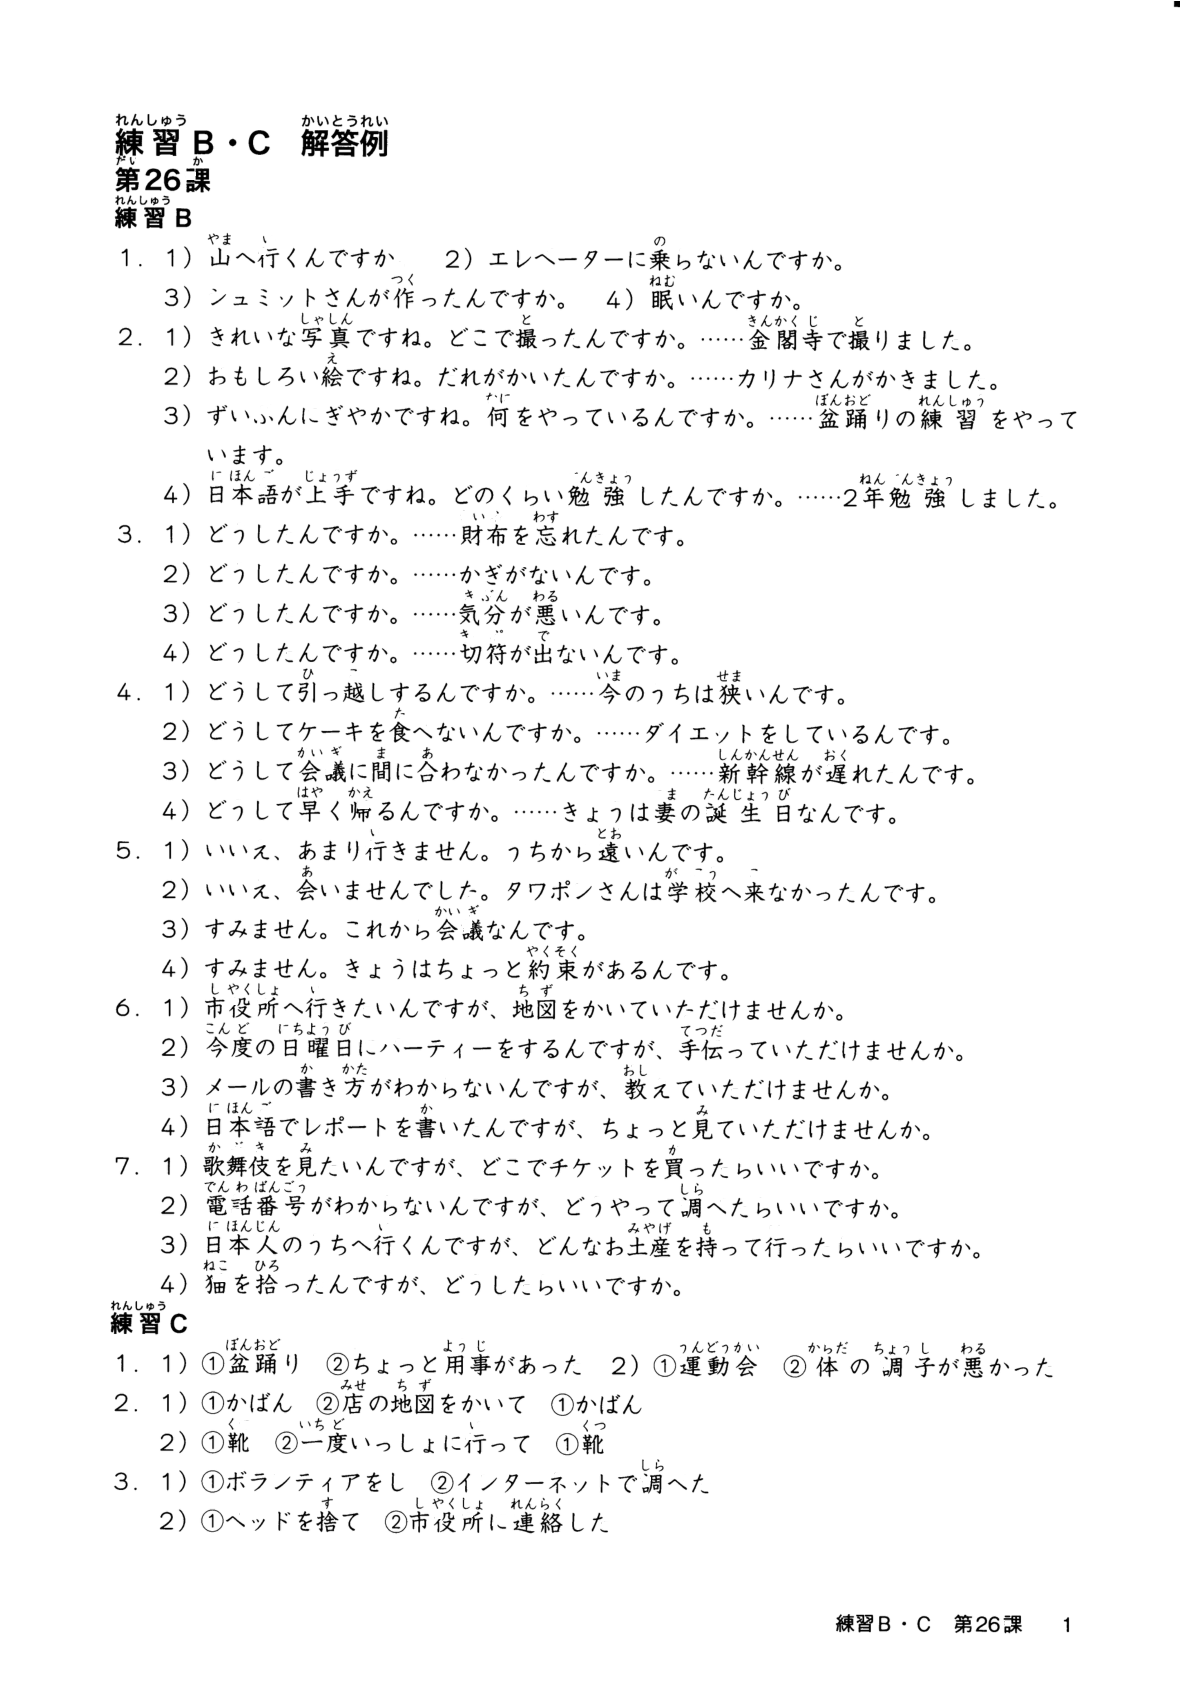

In [54]:
Image.fromarray(k)

In [ ]:
# Define a chat histiry and use `apply_chat_template` to get correctly formatted prompt
# Each value in "content" has to be a list of dicts with types ("text", "image")
conversation = [
    {

      "role": "user",
      "content": [
          {"type": "text", "text": text_prompt},
          {"type": "image"},
        ],
    },
]

prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)

# Process inputs
inputs = processor(text=prompt, images=image, return_tensors="pt").to(model.device)

# Generate response
with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=1024,
        do_sample=False
    )

# Decode and return response
response = processor.decode(output[0], skip_special_tokens=True)

In [18]:
# Use only LLaVA-NeXT
llava_results = extract_japanese_text_from_pdf(
    pdf_path=input_file,
    output_dir=output_dir,
    use_llava=True,
    use_gpt4o=False,
    use_gpt4o_mini=False
)

Processing PDF: /content/drive/MyDrive/Colab Notebooks/input/SinglePage.pdf


Converting PDF pages to images: 100%|██████████| 1/1 [00:01<00:00,  1.11s/it]


Loading LLaVA-NeXT model...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

LLaVA-NeXT model loaded successfully


Processing pages with models: 100%|██████████| 1/1 [01:18<00:00, 78.46s/it]

Could not parse LLaVA JSON from page 1: Expecting value: line 1 column 1 (char 0)
Processing complete. Results saved to /content/drive/MyDrive/Colab Notebooks/output/llava_only_output/


#### Test with a subset of pages first

In [ ]:
import fitz  # PyMuPDF

# Test with just a few pages
pdf_path = "your_textbook.pdf"
doc = fitz.open(pdf_path)
test_pdf_path = "test_sample.pdf"

# Create a sample PDF with first 3 pages
doc.select([0, 1, 2])  # Select first 3 pages
doc.save(test_pdf_path)
doc.close()

openai_api_key = userdata.get('OPENAI_API_KEY')

# Process the sample
sample_results = extract_japanese_text_from_pdf(
    pdf_path=test_pdf_path,
    output_dir="sample_test_output",
    use_llava=True,
    use_gpt4o_mini=True,  # Less expensive than full GPT-4o
    openai_api_key=openai_api_key
)

## Visualizing Results

In [ ]:
# Load results
def load_and_analyze_results(output_dir):
    models = ["llava", "gpt4o", "gpt4o_mini"]
    results = {}

    # Load structured results for each model
    for model in models:
        try:
            with open(f"{output_dir}/final_{model}_structured.json", "r", encoding="utf-8") as f:
                results[model] = json.load(f)
        except FileNotFoundError:
            print(f"No results for {model}")

    # Create analysis dataframe
    analysis = []
    for model, data in results.items():
        total_exercises = 0
        total_sentences = 0

        for chapter in data:
            chapter_exercises = len(chapter.get("exercises", []))
            chapter_sentences = sum(len(ex.get("sentences", [])) for ex in chapter.get("exercises", []))

            total_exercises += chapter_exercises
            total_sentences += chapter_sentences

            analysis.append({
                "model": model,
                "chapter": chapter.get("chapter"),
                "exercises": chapter_exercises,
                "sentences": chapter_sentences
            })

    return pd.DataFrame(analysis)

# Generate visualization
def visualize_model_comparison(output_dir):
    df = load_and_analyze_results(output_dir)

    if df.empty:
        print("No data available for visualization")
        return

    # Create summary by model
    summary = df.groupby("model").sum().reset_index()

    # Plot comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # Exercise count
    summary.plot(kind="bar", x="model", y="exercises", ax=ax1)
    ax1.set_title("Total Exercises Extracted")
    ax1.set_ylabel("Exercise Count")

    # Sentence count
    summary.plot(kind="bar", x="model", y="sentences", ax=ax2)
    ax2.set_title("Total Sentences Extracted")
    ax2.set_ylabel("Sentence Count")

    plt.tight_layout()
    plt.savefig(f"{output_dir}/model_comparison_chart.png")
    plt.show()

    return summary

# Use in notebook
results_summary = visualize_model_comparison("japanese_extraction_output")
print(results_summary)

### Checking Quality of Furigana Handling

In [ ]:
def check_furigana_handling(output_dir, sample_size=5):
    """Sample sentences and check for furigana characters"""
    # Common furigana patterns
    furigana_patterns = {
        "hiragana": "ぁあぃいぅうぇえぉおかがきぎくぐけげこごさざしじすずせぜそぞただちぢっつづてでとどなにぬねのはばぱひびぴふぶぷへべぺほぼぽまみむめもゃやゅゆょよらりるれろゎわゐゑをんゔゕゖ",
        "small_kana": "ぁぃぅぇぉっゃゅょゎ"
    }

    # Load results from each model
    models = ["llava", "gpt4o", "gpt4o_mini"]
    all_sentences = {}

    for model in models:
        try:
            with open(f"{output_dir}/final_{model}_structured.json", "r", encoding="utf-8") as f:
                data = json.load(f)
                sentences = []

                for chapter in data:
                    for exercise in chapter.get("exercises", []):
                        sentences.extend(exercise.get("sentences", []))

                # Randomly sample sentences
                import random
                if len(sentences) > sample_size:
                    sentences = random.sample(sentences, sample_size)

                all_sentences[model] = sentences
        except FileNotFoundError:
            print(f"No results for {model}")

    # Check for furigana patterns
    results = []
    for model, sentences in all_sentences.items():
        for sentence in sentences:
            # Count small kana characters (often used for furigana)
            small_kana_count = sum(sentence.count(char) for char in furigana_patterns["small_kana"])

            results.append({
                "model": model,
                "sentence": sentence,
                "length": len(sentence),
                "small_kana_count": small_kana_count,
                "small_kana_ratio": small_kana_count / len(sentence) if len(sentence) > 0 else 0
            })

    return pd.DataFrame(results)

# Use in notebook
furigana_analysis = check_furigana_handling("japanese_extraction_output")
print(furigana_analysis.groupby("model").mean()[["small_kana_count", "small_kana_ratio"]])

# Gradio

## Gradio functions

In [ ]:
def create_visualization(output_dir):
    """Create visualization and return the image path"""
    try:
        df = load_and_analyze_results(output_dir)

        if df.empty:
            return None, "No data available for visualization"

        # Create summary by model
        summary = df.groupby("model").sum().reset_index()

        # Plot comparison
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

        # Exercise count
        summary.plot(kind="bar", x="model", y="exercises", ax=ax1)
        ax1.set_title("Total Exercises Extracted")
        ax1.set_ylabel("Exercise Count")

        # Sentence count
        summary.plot(kind="bar", x="model", y="sentences", ax=ax2)
        ax2.set_title("Total Sentences Extracted")
        ax2.set_ylabel("Sentence Count")

        plt.tight_layout()

        # Save to a bytes buffer
        buf = io.BytesIO()
        plt.savefig(buf, format='png')
        plt.close()
        buf.seek(0)

        # Create a PIL image
        img = Image.open(buf)

        return img, summary.to_markdown()
    except Exception as e:
        return None, f"Error creating visualization: {str(e)}"

def load_results_data(output_dir, model_name):
    """Load and return results data for a specific model"""
    try:
        with open(f"{output_dir}/final_{model_name}_structured.json", "r", encoding="utf-8") as f:
            data = json.load(f)
        return json.dumps(data, ensure_ascii=False, indent=2)
    except FileNotFoundError:
        return f"No results found for {model_name}"
    except Exception as e:
        return f"Error loading results for {model_name}: {str(e)}"

def create_zip_archive(output_dir):
    """Create a zip archive of all results files"""
    try:
        zip_path = f"{output_dir}/all_results.zip"
        shutil.make_archive(zip_path[:-4], 'zip', output_dir)
        return zip_path
    except Exception as e:
        return f"Error creating zip archive: {str(e)}"

In [ ]:
def process_pdf(
    pdf_file,
    use_llava=True,
    use_gpt4o=False,
    use_gpt4o_mini=False,
    openai_api_key="",
    max_workers=4,
    progress=gr.Progress()
):
    """Process PDF file and return results"""
    try:
        # Create temp directory for output
        with tempfile.TemporaryDirectory() as temp_dir:
            # Save uploaded PDF to temp file
            pdf_path = os.path.join(temp_dir, "input.pdf")
            with open(pdf_path, "wb") as f:
                f.write(pdf_file)

            # Create output directory
            output_dir = os.path.join(temp_dir, "output")
            os.makedirs(output_dir, exist_ok=True)

            # Set up for progress tracking
            progress(0, desc="Processing PDF...")

            # Process PDF
            results = extract_japanese_text_from_pdf(
                pdf_path,
                output_dir,
                use_llava=use_llava,
                use_gpt4o=use_gpt4o,
                use_gpt4o_mini=use_gpt4o_mini,
                openai_api_key=openai_api_key if openai_api_key else None,
                max_workers=max_workers
            )

            progress(0.8, desc="Creating visualization...")

            # Create visualizations
            viz_img, viz_summary = create_visualization(output_dir)

            # Get results for each model
            llava_results = load_results_data(output_dir, "llava") if use_llava else "LLaVA not used"
            gpt4o_results = load_results_data(output_dir, "gpt4o") if use_gpt4o else "GPT-4o not used"
            gpt4o_mini_results = load_results_data(output_dir, "gpt4o_mini") if use_gpt4o_mini else "GPT-4o mini not used"

            # Get comparison if multiple models used
            comparison_results = "No comparison available (need at least two models)"
            if (use_llava and (use_gpt4o or use_gpt4o_mini)) or (use_gpt4o and use_gpt4o_mini):
                try:
                    with open(f"{output_dir}/model_comparison.json", "r", encoding="utf-8") as f:
                        comparison_data = json.load(f)
                    comparison_results = json.dumps(comparison_data, ensure_ascii=False, indent=2)
                except FileNotFoundError:
                    comparison_results = "Comparison file not found"

            # Create zip archive of all results
            progress(0.9, desc="Creating download archive...")
            results_zip = create_zip_archive(output_dir)

            # Copy zip to a persistent location
            persistent_dir = "gradio_downloads"
            os.makedirs(persistent_dir, exist_ok=True)
            persistent_zip = os.path.join(persistent_dir, f"japanese_extraction_{os.path.basename(results_zip)}")
            shutil.copy(results_zip, persistent_zip)

            progress(1.0, desc="Complete!")

            return (
                viz_img,
                viz_summary,
                llava_results,
                gpt4o_results,
                gpt4o_mini_results,
                comparison_results,
                persistent_zip
            )

    except Exception as e:
        return None, f"Error processing PDF: {str(e)}", "", "", "", "", None

## Create Gradio

In [ ]:
def create_gradio_interface():
    """Create and launch the Gradio interface"""
    with gr.Blocks(title="Japanese Text Extraction") as app:
        gr.Markdown("# Japanese Text Extraction from PDF")
        gr.Markdown("""
        This tool extracts Japanese text from textbooks and other PDFs, handling furigana properly.
        You can use multiple models and compare their results.
        """)

        with gr.Row():
            with gr.Column(scale=1):
                pdf_file = gr.File(label="Upload PDF", file_types=[".pdf"])

                with gr.Row():
                    use_llava = gr.Checkbox(label="Use LLaVA-NeXT (Open Source)", value=True)
                    use_gpt4o = gr.Checkbox(label="Use GPT-4o", value=False)
                    use_gpt4o_mini = gr.Checkbox(label="Use GPT-4o mini", value=False)

                openai_api_key = gr.Textbox(
                    label="OpenAI API Key (Required for GPT-4o/mini)",
                    placeholder="sk-...",
                    type="password"
                )

                max_workers = gr.Slider(
                    label="Max Workers (Parallel Processing)",
                    minimum=1,
                    maximum=8,
                    value=4,
                    step=1
                )

                process_button = gr.Button("Process PDF", variant="primary")

            with gr.Column(scale=2):
                viz_img = gr.Image(label="Model Comparison Visualization")
                viz_summary = gr.Markdown(label="Summary")

                with gr.Tabs():
                    with gr.TabItem("LLaVA-NeXT Results"):
                        llava_results = gr.TextArea(label="LLaVA-NeXT Results", lines=10)

                    with gr.TabItem("GPT-4o Results"):
                        gpt4o_results = gr.TextArea(label="GPT-4o Results", lines=10)

                    with gr.TabItem("GPT-4o mini Results"):
                        gpt4o_mini_results = gr.TextArea(label="GPT-4o mini Results", lines=10)

                    with gr.TabItem("Model Comparison"):
                        comparison_results = gr.TextArea(label="Model Comparison", lines=10)

                download_button = gr.File(label="Download All Results")

        process_button.click(
            fn=process_pdf,
            inputs=[pdf_file, use_llava, use_gpt4o, use_gpt4o_mini, openai_api_key, max_workers],
            outputs=[viz_img, viz_summary, llava_results, gpt4o_results, gpt4o_mini_results, comparison_results, download_button]
        )

        gr.Markdown("""
        ## How to use
        1. Upload a PDF containing Japanese text with furigana
        2. Select which models to use
        3. Enter your OpenAI API key if using GPT-4o or GPT-4o mini
        4. Click "Process PDF" and wait for the results
        5. Download the complete results as a ZIP file

        ## Notes
        - LLaVA-NeXT is open source and free to use
        - GPT-4o and GPT-4o mini require an OpenAI API key and will incur usage costs
        - Processing large PDFs may take some time
        """)

    return app

## Launch Gradio

In [ ]:
app = create_gradio_interface()
app.launch()